### Library

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### Loading CSV File

In [2]:
df_clustering = pd.read_csv("cleaned_sensor_data.csv")
print(df_clustering[["Temp", "Humidity", "Sound"]])
print(df_clustering.head())

           Temp   Humidity      Sound
0     27.025712  47.764121  44.074750
1     25.046120  42.021709  41.317915
2     25.970129  48.071642  37.560666
3     24.184103  53.923401  52.164802
4     25.668486  51.190183  50.166251
...         ...        ...        ...
6475  18.402542  46.473557  47.903865
6476  24.795750  47.159906  42.900978
6477  23.542548  48.813112  56.981877
6478  24.430470  44.490120  42.995325
6479  22.822693  54.910373  38.571787

[6480 rows x 3 columns]
             Timestamp       Temp   Humidity      Sound
0  2024-01-01 00:00:00  27.025712  47.764121  44.074750
1  2024-01-01 00:00:00  25.046120  42.021709  41.317915
2  2024-01-01 00:00:00  25.970129  48.071642  37.560666
3  2024-01-01 01:00:00  24.184103  53.923401  52.164802
4  2024-01-01 01:00:00  25.668486  51.190183  50.166251


### Choosing necessary columns

In [3]:
# Using relevant columns from the dataset
X = df_clustering[["Temp", "Humidity", "Sound"]]
#Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Modeling using Clustering

In [4]:
# Train clustering model
kmeans = KMeans(n_clusters=1, random_state=42)
kmeans.fit(X_scaled)

# Distance to cluster centers
distances = kmeans.transform(X_scaled)

# Anomaly score = minimum distance to any cluster center
anomaly_scores = np.min(distances, axis=1)

# Attach scores to dataframe
df_clustering["anomaly_score"] = anomaly_scores

# Calculating the threshold
threshold = df_clustering["anomaly_score"].quantile(0.95)
df_clustering["is_anomaly"] = df_clustering["anomaly_score"] > threshold

# Save model and scaler
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(df_clustering["anomaly_score"])
print(df_clustering["is_anomaly"])
print(threshold)

0       1.589139
1       1.816272
2       1.819129
3       1.649374
4       1.360417
          ...   
6475    2.948462
6476    0.797805
6477    2.426889
6478    1.175208
6479    1.722015
Name: anomaly_score, Length: 6480, dtype: float64
0       False
1       False
2       False
3       False
4       False
        ...  
6475     True
6476    False
6477    False
6478    False
6479    False
Name: is_anomaly, Length: 6480, dtype: bool
2.8251912819000213


### PCA Visualization

[0.33724907 0.33454911 0.32820182]
[0.33724907 0.67179818 1.        ]


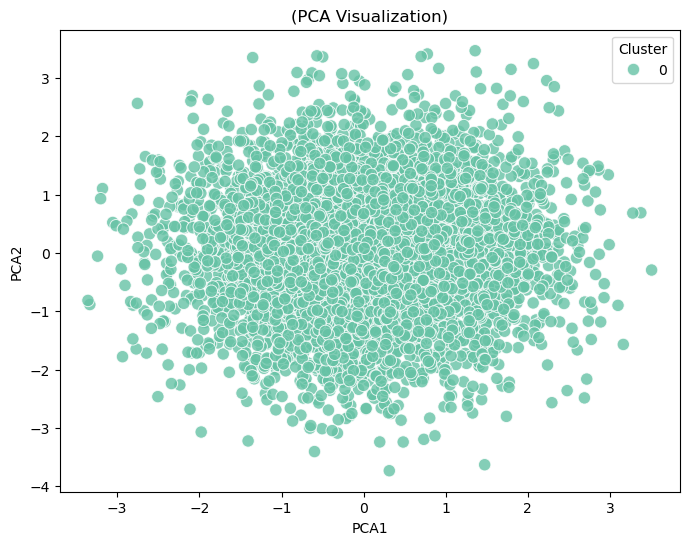

In [5]:
#  Taking 1 cluster for simplicity
kmeans = KMeans(n_clusters=1, random_state=42)
df_clustering['Cluster'] = kmeans.fit_predict(X_scaled)

# doing it the easy way
pca = PCA().fit(X_scaled)

# extract the explaind variance ratios
var_exp = pca.explained_variance_ratio_
print(var_exp)
cum_var_exp = np.cumsum(var_exp)
print(cum_var_exp)

# extract the eigenvectors
eig_vecs = pca.components_

# project the data to a two-dimensional feature space
Y = PCA(n_components=2).fit(X_scaled).transform(X_scaled)

df_clustering['PCA1'] = Y[:,0]
df_clustering['PCA2'] = Y[:,1]

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster',
    palette='Set2', data=df_clustering, s=80, alpha=0.8
)
plt.title('(PCA Visualization)')
plt.legend(title='Cluster')
plt.show()

### Counting the anomalies

In [6]:
print(df_clustering["is_anomaly"].value_counts())


is_anomaly
False    6156
True      324
Name: count, dtype: int64
